In [20]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt 

In [21]:
olivetti_faces = fetch_olivetti_faces()

### Extracting Features and Labels

In [22]:
X = olivetti_faces.data
y = olivetti_faces.target

### Splitting the Dataset into Training and Test Sets

In [25]:
X_reshaped = X.reshape(40, 10, 4096)
y_reshaped = y.reshape(40,10)

X_train = X_reshaped[:, :8, :].reshape(-1,4096)
y_train = y_reshaped[:,:8].reshape(-1)

X_test = X_reshaped[:, 8:, :].reshape(-1,4096)
y_test = y_reshaped[:,8:].reshape(-1)

### Centering the Data and Computing the Covariance Matrix

In [26]:
train_mean = X_train.mean(axis=0)

X_train_centered = X_train - train_mean
X_test_centered = X_test - train_mean

n= X_train_centered.shape[0]
cov_matrix = (X_train_centered.T @ X_train_centered)/(n-1)

### Eigendecomposition of the Covariance Matrix

In [27]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

### Visualizing the First 10 Eigenfaces

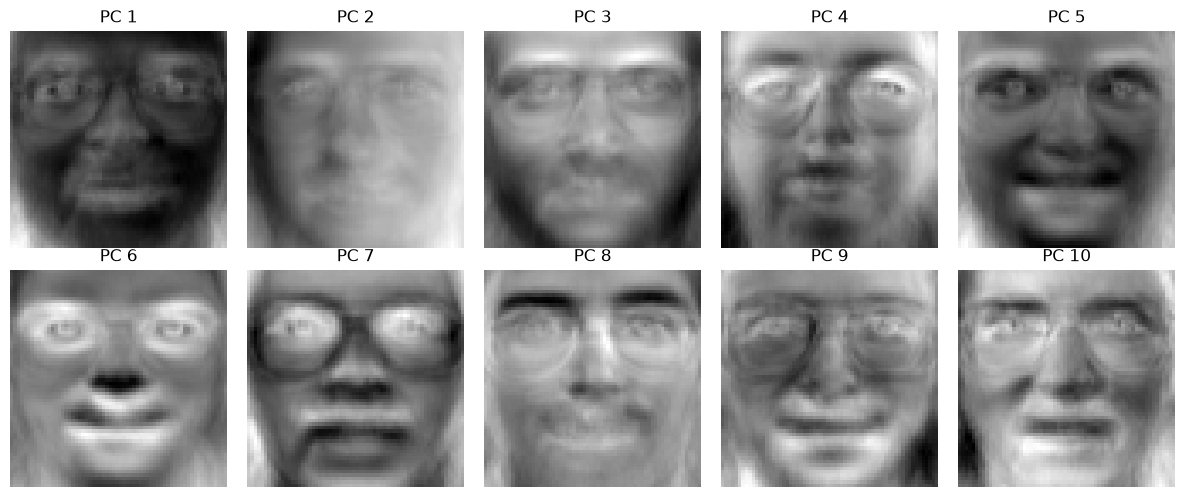

In [28]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    eigenface = eigenvectors[:, i].reshape(64, 64)
    
    ax.imshow(eigenface, cmap="gray")
    ax.set_title(f"PC {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Calculating Reconstruction error for the test set

In [29]:
ks = [10, 50, 150]

for k in ks:
    W_k = eigenvectors[:, :k]

    # Project test data
    Z_test = X_test_centered @ W_k

    # Reconstruct
    X_test_reconstructed = Z_test @ W_k.T + np.mean(X_train, axis=0)

    # Calculate MSE
    mse = np.mean((X_test - X_test_reconstructed) ** 2)

    print(f"k = {k}, MSE = {mse}")

k = 10, MSE = 0.007220243103802204
k = 50, MSE = 0.0036571503151208162
k = 150, MSE = 0.002353532938286662


### Reconstruction error vs number of components

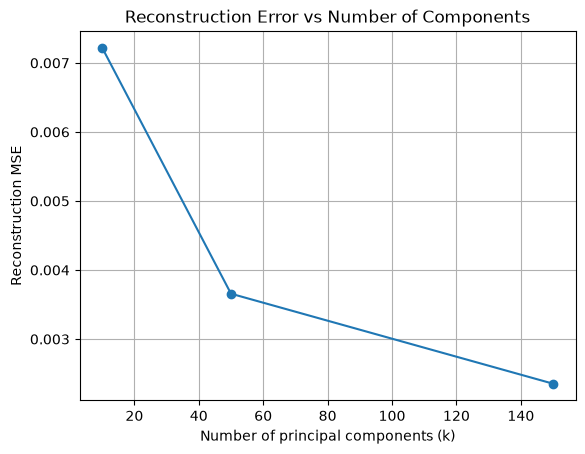

In [52]:
ks = [10, 50, 150]
mse_values = []

for k in ks:
    W_k = eigenvectors[:, :k]

    Z_test = X_test_centered @ W_k
    X_reconstructed = Z_test @ W_k.T + train_mean

    mse = np.mean((X_test - X_reconstructed) ** 2)
    mse_values.append(mse)

plt.plot(ks, mse_values, marker="o")
plt.xlabel("Number of principal components (k)")
plt.ylabel("Reconstruction MSE")
plt.title("Reconstruction Error vs Number of Components")
plt.grid()
plt.show()

### Comparing classification accuracy for different k

In [30]:
ks = [10, 50, 150]

accuracies = []

for k in ks:
    W_k = eigenvectors[:, :k]

    # Project train and test data
    Z_train = X_train_centered @ W_k
    Z_test = X_test_centered @ W_k

    predictions = []

    # 1-NN classification
    for i in range(len(Z_test)):
        test_face = Z_test[i]

        distances = np.linalg.norm(Z_train - test_face, axis=1)

        nearest_index = np.argmin(distances)

        predicted_label = y_train[nearest_index]

        predictions.append(predicted_label)

    predictions = np.array(predictions)

    accuracy = np.mean(predictions == y_test)
    accuracies.append(accuracy)

    print(f"k = {k}, Accuracy = {accuracy:.4f}")

k = 10, Accuracy = 0.8125
k = 50, Accuracy = 0.8875
k = 150, Accuracy = 0.8875


### Classification accuracy vs k

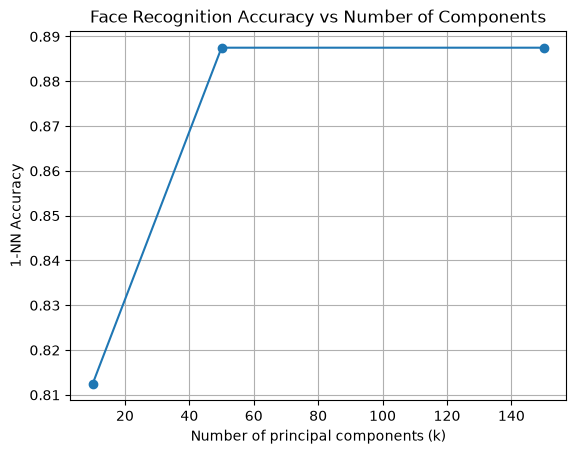

In [53]:
plt.plot(ks, accuracies, marker="o")
plt.xlabel("Number of principal components (k)")
plt.ylabel("1-NN Accuracy")
plt.title("Face Recognition Accuracy vs Number of Components")
plt.grid()
plt.show()

### Getting predictions AND nearest training-image indices

In [31]:
predictions = []
nearest_indices = []

for i in range(len(Z_test)):
    test_face = Z_test[i]

    distances = np.linalg.norm(Z_train - test_face, axis=1)

    nearest_index = np.argmin(distances)

    predictions.append(y_train[nearest_index])
    nearest_indices.append(nearest_index)

predictions = np.array(predictions)
nearest_indices = np.array(nearest_indices)

### Finding the incorrectly classified images

In [32]:
failed_indices = np.where(predictions != y_test)[0]

print("Number of failed predictions:", len(failed_indices))
print("Failed test indices:", failed_indices)
#print("Failed predictions percentage:", len(failed_indices)/len(y_test))

Number of failed predictions: 9
Failed test indices: [ 4  5  7  9 14 17 18 19 30]


### Look at several failed examples

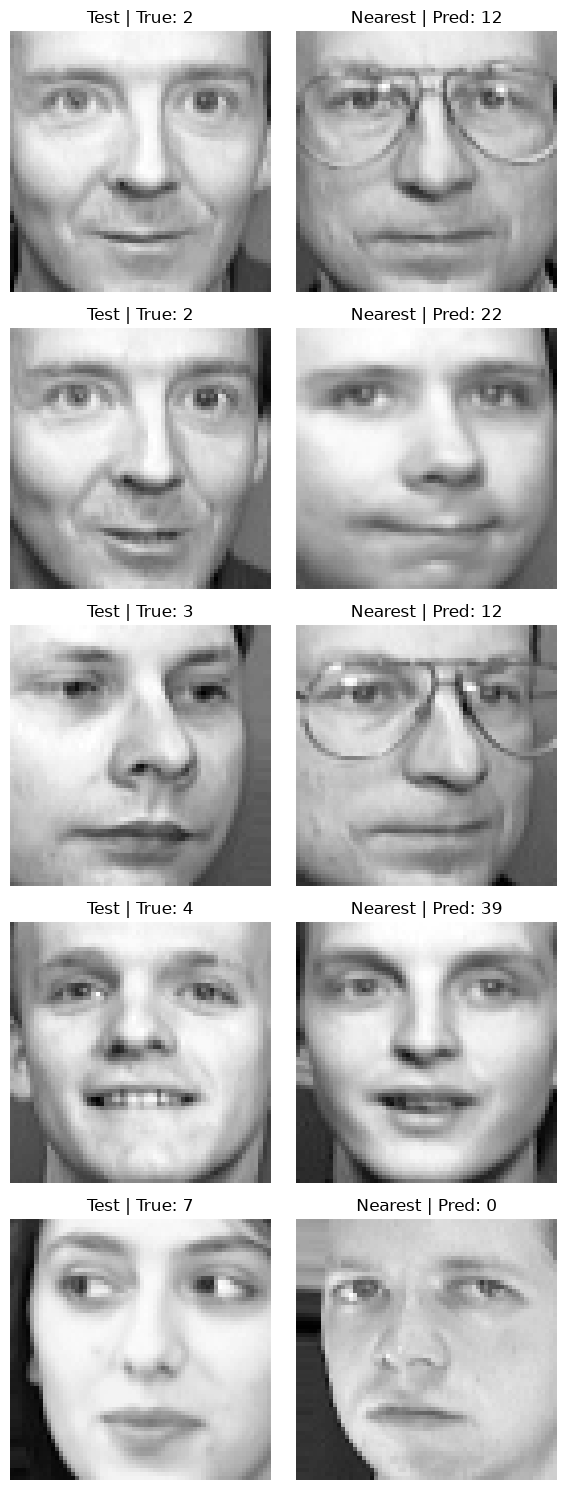

In [33]:
n_show = min(5, len(failed_indices))

fig, axes = plt.subplots(n_show, 2, figsize=(6, 3 * n_show))

for row in range(n_show):
    idx = failed_indices[row]
    nearest_idx = nearest_indices[idx]

    axes[row, 0].imshow(X_test[idx].reshape(64, 64), cmap="gray")
    axes[row, 0].set_title(f"Test | True: {y_test[idx]}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(X_train[nearest_idx].reshape(64, 64), cmap="gray")
    axes[row, 1].set_title(f"Nearest | Pred: {predictions[idx]}")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

## Starting the SVD approach

In [34]:
U, S, Vt = np.linalg.svd(
    X_train_centered,
    full_matrices=False
)

print("U:", U.shape)
print("S:", S.shape)
print("Vt:", Vt.shape)

U: (320, 320)
S: (320,)
Vt: (320, 4096)


### Getting the PCA directions from SVD

In [35]:
svd_eigenvectors = Vt.T

print(svd_eigenvectors.shape)

(4096, 320)


### Compare eigenvalues from covariance PCA and SVD

λi​=  Si**2 / n-1​​

In [36]:
n = X_train_centered.shape[0]

svd_eigenvalues = S**2 / (n - 1)

print("First 10 covariance eigenvalues:")
print(eigenvalues[:10])

print("\nFirst 10 SVD eigenvalues:")
print(svd_eigenvalues[:10])

First 10 covariance eigenvalues:
[18.500557  10.145485   6.2814713  4.1127677  2.9456367  2.6476798
  2.0293467  1.7040573  1.57495    1.4372678]

First 10 SVD eigenvalues:
[18.500559  10.145484   6.2814717  4.112767   2.9456365  2.6476798
  2.0293467  1.7040573  1.5749499  1.4372678]


### Getting PCA components from SVD

In [39]:
svd_components = Vt.T

print(svd_components.shape)

(4096, 320)


### Comparing the first principal direction
PCA doesn't care whether the direction points one way or the opposite way.

In [40]:
pc_cov = eigenvectors[:, 0]
pc_svd = svd_components[:, 0]

dot_product = np.dot(pc_cov, pc_svd)

print("Dot product:", dot_product)

Dot product: 1.0


### Comparing the first eigenfaces visually

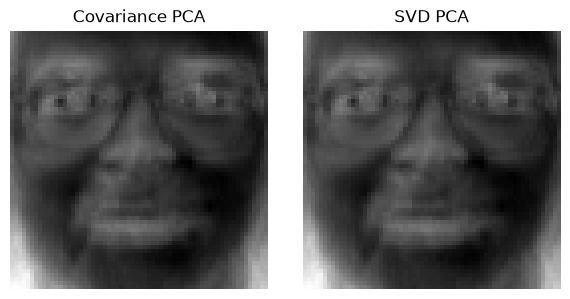

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(
    eigenvectors[:, 0].reshape(64, 64),
    cmap="gray"
)
axes[0].set_title("Covariance PCA")
axes[0].axis("off")

axes[1].imshow(
    svd_components[:, 0].reshape(64, 64),
    cmap="gray"
)
axes[1].set_title("SVD PCA")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Comparing reconstruction from both methods
Now we have two reconstructed versions of the same test face.

In [47]:
k = 50

W_cov = eigenvectors[:, :k]
W_svd = svd_components[:, :k]

x = X_test[0] - train_mean

reconstruction_cov = (
    x @ W_cov @ W_cov.T
) + train_mean

reconstruction_svd = (
    x @ W_svd @ W_svd.T
) + train_mean

### Visualizing both reconstructions
They should be visually almost identical.

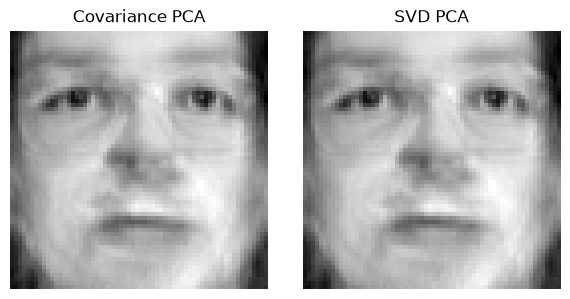

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(
    reconstruction_cov.reshape(64, 64),
    cmap="gray"
)
axes[0].set_title("Covariance PCA")
axes[0].axis("off")

axes[1].imshow(
    reconstruction_svd.reshape(64, 64),
    cmap="gray"
)
axes[1].set_title("SVD PCA")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Numerically compare the reconstructions
This tells us that although we used two different mathematical approaches, we're essentially getting the same reconstruction.

In [49]:
difference = np.mean(
    (reconstruction_cov - reconstruction_svd) ** 2
)

print("MSE between reconstructions:", difference)

MSE between reconstructions: 1.6382837e-15


### Compare the PCA subspaces

In [50]:
k = 50

W_cov = eigenvectors[:, :k]
W_svd = svd_components[:, :k]

P_cov = W_cov @ W_cov.T
P_svd = W_svd @ W_svd.T

subspace_difference = np.linalg.norm(
    P_cov - P_svd
)

print("Subspace difference:", subspace_difference)

Subspace difference: 3.3690005e-06


### Compare reconstruction error for SVD

In [51]:
ks = [10, 50, 150]

for k in ks:
    W_svd = Vt[:k].T

    Z_test = X_test_centered @ W_svd

    X_test_reconstructed = (
        Z_test @ W_svd.T
    ) + train_mean

    mse = np.mean(
        (X_test - X_test_reconstructed) ** 2
    )

    print(
        f"k = {k}, "
        f"SVD reconstruction MSE = {mse:.6f}"
    )

k = 10, SVD reconstruction MSE = 0.007220
k = 50, SVD reconstruction MSE = 0.003657
k = 150, SVD reconstruction MSE = 0.002354


### How robust is our PCA-based face recognition system when the test images are corrupted?

## Adding Gaussian noise to the test images

1. Choose a noise level
2. Generate the noise
3. Add the noise
4. Keep pixel values in a valid range (Because adding noise can make some pixels smaller than 0 or larger than 1, clip them)

In [54]:
sigma = 0.05

noise = np.random.normal(
    loc=0,
    scale=sigma,
    size=X_test.shape
)

X_test_noisy = X_test + noise
X_test_noisy = np.clip(X_test_noisy, 0, 1)

### Plotting what the noise did

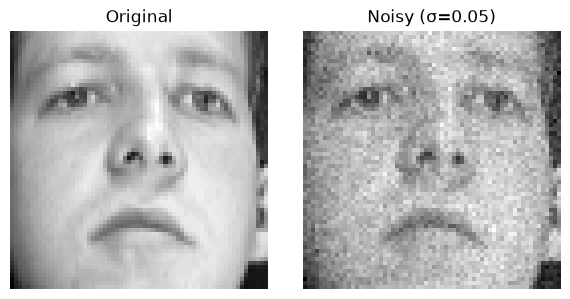

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(X_test[0].reshape(64, 64), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(X_test_noisy[0].reshape(64, 64), cmap="gray")
axes[1].set_title(f"Noisy (σ={sigma})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### PCA Projection of Noisy Test Data

In [56]:
k = 50

W_k = eigenvectors[:, :k]

X_test_noisy_centered = X_test_noisy - train_mean

Z_train = X_train_centered @ W_k
Z_test_noisy = X_test_noisy_centered @ W_k

### 1-NN Recognition on Noisy Images

In [57]:
predictions_noisy = []

for test_face in Z_test_noisy:
    distances = np.linalg.norm(Z_train - test_face, axis=1)
    nearest_index = np.argmin(distances)
    predictions_noisy.append(y_train[nearest_index])

predictions_noisy = np.array(predictions_noisy)

### Calculate Recognition Accuracy

In [58]:
accuracy_noisy = np.mean(predictions_noisy == y_test)

print(f"Accuracy with noise (σ={sigma}): {accuracy_noisy:.4f}")

Accuracy with noise (σ=0.05): 0.8875


### Compare Different Noise Levels

In [59]:
sigmas = [0, 0.02, 0.05, 0.1, 0.2]
accuracies_noisy = []

k = 50
W_k = eigenvectors[:, :k]

Z_train = X_train_centered @ W_k

for sigma in sigmas:

    noise = np.random.normal(
        0, sigma, X_test.shape
    )

    X_test_noisy = np.clip(X_test + noise, 0, 1)
    X_test_noisy_centered = X_test_noisy - train_mean

    Z_test_noisy = X_test_noisy_centered @ W_k

    predictions = []

    for test_face in Z_test_noisy:
        distances = np.linalg.norm(Z_train - test_face, axis=1)
        nearest_index = np.argmin(distances)
        predictions.append(y_train[nearest_index])

    predictions = np.array(predictions)

    accuracy = np.mean(predictions == y_test)
    accuracies_noisy.append(accuracy)

### Plotting Accuracy vs. Noise Level

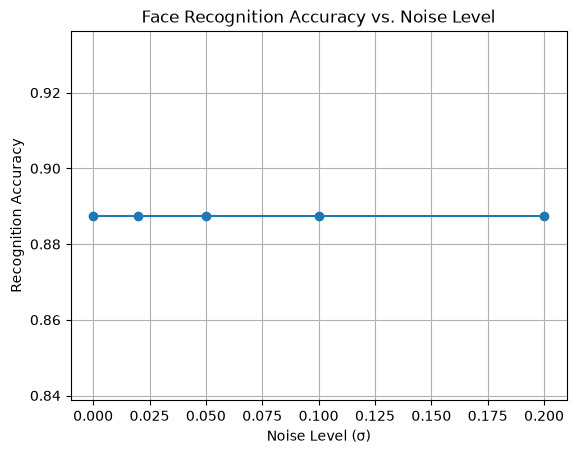

In [60]:
plt.plot(sigmas, accuracies_noisy, marker="o")

plt.xlabel("Noise Level (σ)")
plt.ylabel("Recognition Accuracy")
plt.title("Face Recognition Accuracy vs. Noise Level")

plt.grid()
plt.show()